<a href="https://colab.research.google.com/github/adihatake/Improving-OCT-Interpretation-through-Retrieval-Guided-Diagnosis-and-LLM-Based-Reporting/blob/main/Indicium_ResNet50_Evaluations_and_Benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README!
**Cells required to execute:**
1. Load the dependencies
2. Load datasets from dis
3. Preprocess the data
4. Define the model
5. Load model from disk

---





# Load dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
! pip install -U datasets
! pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import datasets
import numpy as np
import random
import faiss
import pickle
import io


from PIL import Image
from datasets import load_dataset, load_from_disk
from scipy import stats
from collections import Counter

from torch.utils.data import DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.manifold import TSNE

from tqdm import tqdm


# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Load datasets from disk

In [ ]:
# Load datasets locally
raw_train_data = load_dataset("parquet", data_files="/content/drive/MyDrive/Indicium/OLIVES_train_seed42.parquet")['train']
raw_val_data = load_dataset("parquet", data_files="/content/drive/MyDrive/Indicium/OLIVES_val_seed42.parquet")['train']
raw_test_data = load_dataset("parquet", data_files="/content/drive/MyDrive/Indicium/OLIVES_test_seed42.parquet")['train']

biomarker_benchmark = load_dataset("parquet", data_files="/content/drive/MyDrive/Indicium/OLIVES_biomarker_benchmark_dataset.parquet")['train']

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
print(f"Train size: {len(raw_train_data)}")
print(f"Test size: {len(raw_test_data)}")
print(f"Validation size: {len(biomarker_benchmark)}")

Train size: 14247
Test size: 1568
Validation size: 3871


In [ ]:
print(biomarker_benchmark[0])

{'Image': <PIL.TiffImagePlugin.TiffImageFile image mode=L size=504x496 at 0x7F8DD6E9DD90>, 'B1': 0.0, 'B2': 0.0, 'B3': 1.0, 'B4': 1.0, 'B5': 0.0, 'B6': 0.0}


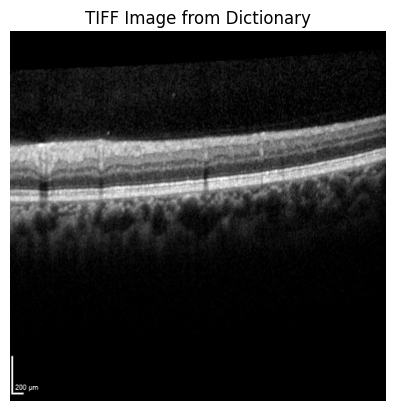

In [ ]:
from PIL import Image

sample1 = biomarker_benchmark[0]

# Open an image file
img = sample1['Image']

# Convert to NumPy array
img_array = np.array(img)

# Plot
plt.imshow(img_array, cmap='gray')  # use cmap='gray' for grayscale (mode 'L')
plt.title("TIFF Image from Dictionary")
plt.axis('off')
plt.show()

In [ ]:
sample1 = raw_train_data[0]

for key, value in list(sample1.items())[1:]:
    print(key, value)

Atrophy / thinning of retinal layers 0.0
Disruption of EZ 0.0
DRIL 0.0
IR hemorrhages 0.0
IR HRF 1.0
Partially attached vitreous face 0.0
Fully attached vitreous face 1.0
Preretinal tissue/hemorrhage 0.0
Vitreous debris 1.0
VMT 0.0
DRT/ME 0.0
Fluid (IRF) 1.0
Fluid (SRF) 0.0
Disruption of RPE 0.0
PED (serous) 0.0
SHRM 0.0
Patient_ID 58
Disease Label 0.0
__index_level_0__ 0


In [ ]:
from collections import Counter

# Get frequency of disease labels in each class
train_label_counts = Counter(raw_train_data['Disease Label'])
print("\nTrain disease label counts:")
print(train_label_counts)

val_label_counts = Counter(raw_val_data['Disease Label'])
print("\nValidation disease label counts:")
print(val_label_counts)

test_label_counts = Counter(raw_test_data['Disease Label'])
print("\nTest disease label counts:")
print(test_label_counts)



Train disease label counts:
Counter({1.0: 7975, 0.0: 6272})

Validation disease label counts:
Counter({1.0: 968, 0.0: 686})

Test disease label counts:
Counter({0.0: 784, 1.0: 784})


# Preprocess the data
This includes converting the images to RGB and applying ResNet50's standard preprocessing and one-hot encoding the biomarkers.

In [ ]:
# Define biomarker fields
biomarker_fields = [
    "Atrophy / thinning of retinal layers",
    "Disruption of EZ",
    "DRIL",
    "IR hemorrhages",
    "IR HRF",
    "Partially attached vitreous face",
    "Fully attached vitreous face",
    "Preretinal tissue/hemorrhage",
    "Vitreous debris",
    "VMT",
    "DRT/ME",
    "Fluid (IRF)",
    "Fluid (SRF)",
    "Disruption of RPE",
    "PED (serous)",
    "SHRM"
]


# Map B-fields to their corresponding index
benchmark_map = {'B1': 4, 'B2': 5, 'B3': 6, 'B4': 11, 'B5': 10, 'B6': 8}


# Define transforms for validation and test datasets
resnet_transform = transforms.Compose([
    transforms.Resize(256),                        # Resize shorter side to 256
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to RGB
    transforms.ToTensor(),                 # Converts to [C, H, W] in range [0, 1]
    transforms.Normalize(                  # Standard ImageNet normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Define transforms for the training data.
# Here we use the standard ResNet transform but apply random augmentations
train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.4, contrast=0.4),  # ±40% brightness and contrast
    transforms.RandomHorizontalFlip(p=0.5),                # 50% horizontal flip
    transforms.RandomRotation(degrees=8),                  # ±8° rotation
    transforms.RandomResizedCrop(224,                      # ResNet expects 224x224
                                 scale=(0.25, 1.0),
                                 ratio=(0.75, 1.33)),
    transforms.Grayscale(num_output_channels=3),           # Convert grayscale to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class RetinalDataset(torch.utils.data.Dataset):
    def __init__(self, data, biomarker_fields=None, benchmark_map=None, transform=None, isBenchmark=False):
        self.data = data
        self.biomarker_fields = biomarker_fields
        self.benchmark_map = benchmark_map
        self.isBenchmark = isBenchmark
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

      if self.isBenchmark:
        item = self.data[idx]
        img = item['Image']

        if self.transform:
            img = self.transform(img)

        biomarkers = [0] * 16

        for biomarker, index in self.benchmark_map.items():
            biomarkers[index] = item[biomarker]

        biomarkers = torch.tensor(biomarkers, dtype=torch.float32)



        return {
            'image pixel values': img,
            'biomarkers': biomarkers
        }



      else:
        item = self.data[idx]
        img_bytes = item['Image']['bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        if self.transform:
            img = self.transform(img)



        biomarkers = [item[field] for field in self.biomarker_fields]
        biomarkers = torch.tensor(biomarkers, dtype=torch.float32)

        return {
            'image pixel values': img,
            'biomarkers': biomarkers,
            'label': item['Disease Label'],
            'patient id': item['Patient_ID']
        }



# Define the training and test torch Datasets
processed_train_data = RetinalDataset(
    data=raw_train_data,
    biomarker_fields=biomarker_fields,
    transform=train_transform
)


processed_val_data = RetinalDataset(
    data=raw_val_data,
    biomarker_fields=biomarker_fields,
    transform=resnet_transform
)


processed_test_data = RetinalDataset(
    data=raw_test_data,
    biomarker_fields=biomarker_fields,
    transform=resnet_transform
)

biomarker_benchmark_data = RetinalDataset(
    data=biomarker_benchmark,
    biomarker_fields=biomarker_fields,
    benchmark_map=benchmark_map,
    isBenchmark=True,
    transform=resnet_transform
)


In [ ]:
import torch
import numpy as np
import random

# Define a manual seeding function to consistently shuffle the datasets
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42) # Set anual seed to 42 by convention


BATCH_SIZE = 32

# Wrap the datasets to a torch DataLoader to generate batches
# Here, arrange into batches, shuffle the dataset and use
# num_workers to maximize CPU cores for fetching.

train_dataloader = DataLoader(processed_train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=4,
                              worker_init_fn=seed_worker,
                              generator=g)

validation_dataloader = DataLoader(processed_val_data,
                                   batch_size=BATCH_SIZE,
                                   shuffle=False,
                                   num_workers=4,
                                   worker_init_fn=seed_worker,
                                   generator=g)

# Used for model testing
test_dataloader = DataLoader(processed_test_data, batch_size=1, shuffle=False)

# Used for biomarker benchmarking
biomarker_benchmark_dataloader = DataLoader(biomarker_benchmark_data, batch_size=1, shuffle=False)

In [ ]:
print(len(biomarker_benchmark))

3871


# Define model
---



In [ ]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [ ]:
class OCT_net(nn.Module):
    def __init__(self, num_biomarkers=16, num_diseases=2):
        super().__init__()

        # Load pre-trained ResNet50 and replace FC with identity
        pre_trained_model = resnet50(weights=ResNet50_Weights.DEFAULT)
        pre_trained_model.fc = nn.Identity()


        self.backbone = pre_trained_model
        self.feature_dim = 2048  # Output of resnet50 with identity FC

        # Biomarker regression head
        self.biomarker_head = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_biomarkers)
        )

        # Disease classification head
        self.disease_head = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_diseases)
        )

    def forward(self, x, return_features=False):
        x = self.backbone(x)  # Shape: (B, 2048)

        biomarker_logits = self.biomarker_head(x)
        disease_logits = self.disease_head(x)

        if return_features:
            biomarker_feats = self.biomarker_head[:-1](x)
            disease_feats = self.disease_head[:-1](x)
            combined = torch.cat([biomarker_feats, disease_feats], dim=1)
            embedding = F.normalize(combined, dim=1, p=2)
            return biomarker_logits, disease_logits, embedding

        return biomarker_logits, disease_logits


model = OCT_net()
#print(model)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


# Load trained model from disk

In [ ]:
# Check the device to either enable CPU or GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Load checkpoint
checkpoint_path = "/content/drive/MyDrive/Indicium/model_checkpoints/Jun_21_augmentations_finetuning/model_epoch_8.pth"  # or whichever checkpoint we want
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load the model's sate dictionary, weights, gradients and optimizer
model.load_state_dict(checkpoint['model_state_dict'])

# put model to device
model.to(device)

OCT_net(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
         

# Plot learning curves

Get losses from the transfer learning model

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Specify the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define lists for plotting later
loaded_train_losses = []
loaded_val_losses = []
loaded_train_accuracies = []
loaded_val_accuracies = []

transfer_learning_epochs = 5  # Adjust based on checkpoints

for epoch in range(1, transfer_learning_epochs + 1):
    checkpoint_path = f"/content/drive/MyDrive/Indicium/model_checkpoints/Jun_21_augmentations_transferlearning/model_epoch_{epoch}.pth"
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Save the losses for plotting later
    epoch_train_losses = checkpoint.get('train_losses', [])
    epoch_val_losses = checkpoint.get('val_losses', [])
    epoch_train_accuracies = checkpoint.get('train_accuracies', [])
    epoch_val_accuracies = checkpoint.get('val_accuracies', [])

    loaded_train_losses.append(epoch_train_losses[epoch - 1])
    loaded_val_losses.append(epoch_val_losses[epoch - 1])
    loaded_train_accuracies.append(epoch_train_accuracies[epoch - 1])
    loaded_val_accuracies.append(epoch_val_accuracies[epoch - 1])

Get losses from the finetuned model

In [ ]:
fine_tuning_epochs = 10  # Adjust based on checkpoints

for epoch in range(1, fine_tuning_epochs + 1):
    checkpoint_path = f"/content/drive/MyDrive/Indicium/model_checkpoints/Jun_21_augmentations_finetuning/model_epoch_{epoch}.pth"
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Save the losses for plotting later
    epoch_train_losses = checkpoint.get('train_losses', [])
    epoch_val_losses = checkpoint.get('val_losses', [])
    epoch_train_accuracies = checkpoint.get('train_accuracies', [])
    epoch_val_accuracies = checkpoint.get('val_accuracies', [])

    loaded_train_losses.append(epoch_train_losses[epoch - 1])
    loaded_val_losses.append(epoch_val_losses[epoch - 1])
    loaded_train_accuracies.append(epoch_train_accuracies[epoch - 1])
    loaded_val_accuracies.append(epoch_val_accuracies[epoch - 1])

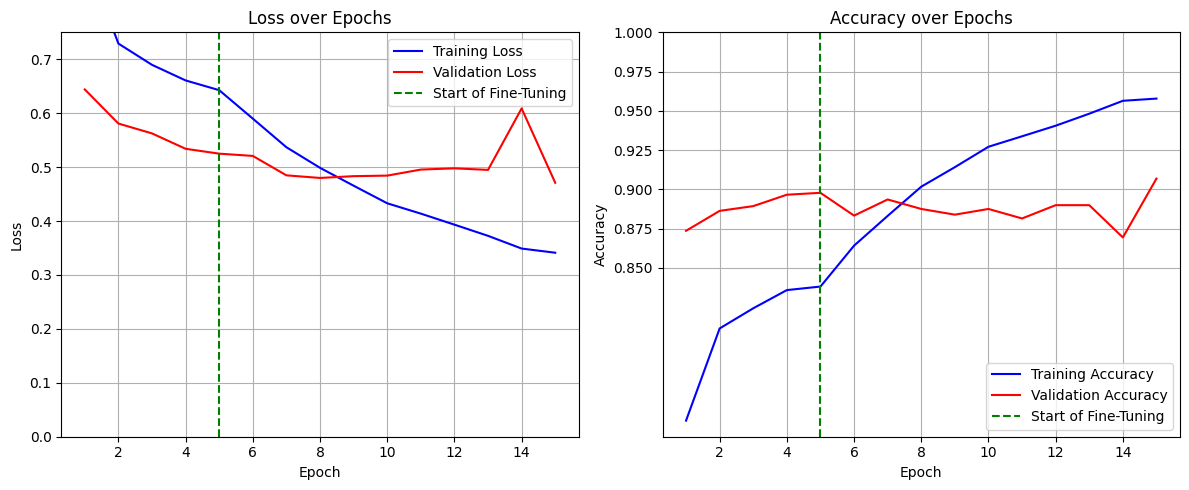

In [ ]:
epochs_to_plot = range(1, transfer_learning_epochs + fine_tuning_epochs + 1)

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_to_plot, loaded_train_losses, 'b-', label='Training Loss')
plt.plot(epochs_to_plot, loaded_val_losses, 'r-', label='Validation Loss')
plt.axvline(x=transfer_learning_epochs, color='g', linestyle='--', label='Start of Fine-Tuning')  # Start line


plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.ylim(0, 0.75)
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_to_plot, loaded_train_accuracies, 'b-', label='Training Accuracy')
plt.plot(epochs_to_plot, loaded_val_accuracies, 'r-', label='Validation Accuracy')
plt.axvline(x=transfer_learning_epochs, color='g', linestyle='--', label='Start of Fine-Tuning')  # Start line

plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.yticks(np.arange(0.85, 1.00, 0.025))
plt.legend()

plt.tight_layout()
plt.show()

# Benchmark test data

In [ ]:
labels_array = np.load(f"/content/drive/MyDrive/Indicium/FAISS_indexes/Jun_21_Jun21-epoch18-finetuned/oct_labels.npy")
biomarkers_array = np.load(f"/content/drive/MyDrive/Indicium/FAISS_indexes/Jun_21_Jun21-epoch18-finetuned/oct_biomarkers.npy")
index = faiss.read_index(f"/content/drive/MyDrive/Indicium/FAISS_indexes/Jun_21_Jun21-epoch18-finetuned/oct_features.index")

In [ ]:
biomarker_fields = [
      "Atrophy / thinning of retinal layers",
      "Disruption of EZ",
      "DRIL",
      "IR hemorrhages",
      "IR HRF",
      "Partially attached vitreous face",
      "Fully attached vitreous face",
      "Preretinal tissue/hemorrhage",
      "Vitreous debris",
      "VMT",
      "DRT/ME",
      "Fluid (IRF)",
      "Fluid (SRF)",
      "Disruption of RPE",
      "PED (serous)",
      "SHRM"
  ]

# Target biomarkers
biomarker_targets = [
      "Fluid (IRF)",
      "IR HRF",
      "Fully attached vitreous face",
      "Partially attached vitreous face",
      "DRT/ME",
      "Vitreous debris"
  ]




def evaluate_model(model, data_loader, isBenchmark, usingFAISS):
  global biomarker_fields, biomarker_targets

  # Create mapping of target biomarker name to index
  biomarker_index_map = {}
  for name in biomarker_targets:
      biomarker_index_map[name] = biomarker_fields.index(name)

  # Create empty prediction and target dictionaries for biomarkers
  biomarker_all_preds = {}
  biomarker_all_targets = {}

  for name in biomarker_fields: #biomarker_targets
      biomarker_all_preds[name] = []
      biomarker_all_targets[name] = []

  # Create prediction and target lists for disease labels
  disease_all_preds = []
  disease_all_targets = []

  model.eval()

  if isBenchmark:
    if usingFAISS:
      benchmark_map = {'B1': 4, 'B2': 5, 'B3': 6, 'B4': 11, 'B5': 10, 'B6': 8}
      benchmark_indices = [benchmark_map[name] for name in benchmark_map]

      with torch.no_grad():
          for batch in tqdm(data_loader, desc="Calculating evaluation metrics"):
              images = batch['image pixel values'].to(device)
              biomarkers = batch['biomarkers'].float().to(device)

              _, __, features = model(images, return_features=True)


              D, I = index.search(features.cpu().numpy().astype("float32"), 5)


              topk_biomarkers = biomarkers_array[I[0]]
              biomarker_preds = np.zeros(topk_biomarkers.shape[1])
              for col in benchmark_indices:
                  col_values = topk_biomarkers[:, col]
                  mode_val = stats.mode(col_values, keepdims=True).mode[0]
                  biomarker_preds[col] = mode_val

              biomarker_preds = torch.tensor(biomarker_preds, dtype=torch.float32)
              biomarker_preds = biomarker_preds.unsqueeze(0)

              # Collect biomarker preds and targets
              for name in biomarker_targets:
                  idx = biomarker_index_map[name]
                  biomarker_all_preds[name].extend(biomarker_preds[:, idx].cpu().numpy())
                  biomarker_all_targets[name].extend(biomarkers[:, idx].cpu().numpy())

    else:
      with torch.no_grad():
          for batch in tqdm(data_loader, desc="Calculating evaluation metrics"):
              images = batch['image pixel values'].to(device)
              biomarkers = batch['biomarkers'].float().to(device)

              biomarker_logits, __ = model(images)

              biomarker_preds = torch.sigmoid(biomarker_logits) > 0.5

              # Collect biomarker preds and targets
              for name in biomarker_targets:
                  idx = biomarker_index_map[name]
                  biomarker_all_preds[name].extend(biomarker_preds[:, idx].cpu().numpy())
                  biomarker_all_targets[name].extend(biomarkers[:, idx].cpu().numpy())



  else:
    benchmark_map = {'B1': 4, 'B2': 5, 'B3': 6, 'B4': 11, 'B5': 10, 'B6': 8}
    benchmark_indices = [benchmark_map[name] for name in benchmark_map]

    if usingFAISS:
      with torch.no_grad():
          for batch in tqdm(data_loader, desc="Calculating evaluation metrics"):
              images = batch['image pixel values'].to(device)
              biomarkers = batch['biomarkers'].float().to(device)
              disease_labels = batch['label'].long().to(device)

              _, __, features = model(images, return_features=True)


              D, I = index.search(features.cpu().numpy().astype("float32"), 5)

              topk_labels = labels_array[I[0]]
              mode_label = Counter(topk_labels).most_common(1)[0][0]
              disease_preds = np.array([mode_label])

              topk_biomarkers = biomarkers_array[I[0]]
              biomarker_preds = np.zeros(topk_biomarkers.shape[1])
              for col in benchmark_indices:
                  col_values = topk_biomarkers[:, col]
                  mode_val = stats.mode(col_values, keepdims=True).mode[0]
                  biomarker_preds[col] = mode_val

              biomarker_preds = torch.tensor(biomarker_preds, dtype=torch.float32)
              biomarker_preds = biomarker_preds.unsqueeze(0)

              # Collect biomarker preds and targets
              for name in biomarker_targets:
                  idx = biomarker_index_map[name]
                  biomarker_all_preds[name].extend(biomarker_preds[:, idx].cpu().numpy())
                  biomarker_all_targets[name].extend(biomarkers[:, idx].cpu().numpy())

              # Collect disease preds and targets for DME evaluation
              disease_all_preds.extend(disease_preds)
              disease_all_targets.extend(disease_labels.cpu().numpy())

    else:
      with torch.no_grad():
          for batch in tqdm(data_loader, desc="Calculating evaluation metrics"):
              images = batch['image pixel values'].to(device)
              biomarkers = batch['biomarkers'].float().to(device)
              disease_labels = batch['label'].long().to(device)

              biomarker_logits, disease_logits = model(images)

              biomarker_preds = torch.sigmoid(biomarker_logits) > 0.5


              # Collect biomarker preds and targets
              for name in biomarker_fields: #biomarker_targets
                  idx = biomarker_fields.index(name)
                  biomarker_all_preds[name].extend(biomarker_preds[:, idx].cpu().numpy())
                  biomarker_all_targets[name].extend(biomarkers[:, idx].cpu().numpy())


              disease_labels = disease_labels
              disease_logits = disease_logits
              disease_preds = disease_logits.argmax(dim=1)

              # Collect disease preds and targets for DME evaluation
              disease_all_preds.extend(disease_preds.cpu().numpy())
              disease_all_targets.extend(disease_labels.cpu().numpy())

  return biomarker_all_preds, biomarker_all_targets, disease_all_preds, disease_all_targets



def produce_biomarker_confusion_matrices(biomarker_all_preds, biomarker_all_targets, biomarker_targets):
  for biomarker_name in biomarker_targets:
      y_true = biomarker_all_targets[biomarker_name]
      y_pred = biomarker_all_preds[biomarker_name]

      cm = confusion_matrix(y_true, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Absent", "Present"])

      disp.plot(cmap=plt.cm.Blues)
      plt.title(f"Confusion Matrix: {biomarker_name}")
      plt.show()




def produce_classification_report(biomarker_all_preds, biomarker_all_targets, disease_all_preds, disease_all_targets, biomarker_targets):
  # Convert lists to numpy arrays for easier indexing
  disease_all_targets_np = np.array(disease_all_targets)
  disease_all_preds_np = np.array(disease_all_preds)

  # The disease labels must be passed in the specified
  # order since the labeling map is: label_map = {0: "DR", 1: "DME"}

  if len(disease_all_targets) > 1:
    print(classification_report(disease_all_targets_np, disease_all_preds_np, target_names=["DR", "DME"]))

  biomarker_f1s = []
  biomarker_accs = []
  biomarker_precisions = []
  biomarker_recalls = []

  # Compute metrics for biomarkers
  for name in biomarker_targets:
      acc = accuracy_score(biomarker_all_targets[name], biomarker_all_preds[name])
      f1 = f1_score(biomarker_all_targets[name], biomarker_all_preds[name], average="binary")
      prec = precision_score(biomarker_all_targets[name], biomarker_all_preds[name], zero_division=0)
      rec = recall_score(biomarker_all_targets[name], biomarker_all_preds[name], zero_division=0)

      biomarker_f1s.append(f1)
      biomarker_accs.append(acc)
      biomarker_precisions.append(prec)
      biomarker_recalls.append(rec)

      print(f"\n{name} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 Score: {f1:.4f}")

  # Compute overall macro-average F1-score and print out other metrics
  macro_f1_all = sum(biomarker_f1s) / len(biomarker_f1s)
  print(f"\nMacro-average F1-score across all biomarkers: {macro_f1_all:.4f}")
  print(f"Macro-average accuracy across all biomarkers: {sum(biomarker_accs) / len(biomarker_accs):.4f}")





In [ ]:
isBenchmark = True
usingFAISS = False

"""
Benchmark:
KNN by FAISS
Regular Model

Test Split
KNN by FAISS
Regular Model


"""




biomarker_all_preds, biomarker_all_targets, disease_all_preds, disease_all_targets = evaluate_model(model=model, data_loader=biomarker_benchmark_dataloader, isBenchmark=isBenchmark, usingFAISS=usingFAISS)

Calculating evaluation metrics: 100%|██████████| 3871/3871 [00:43<00:00, 89.78it/s]


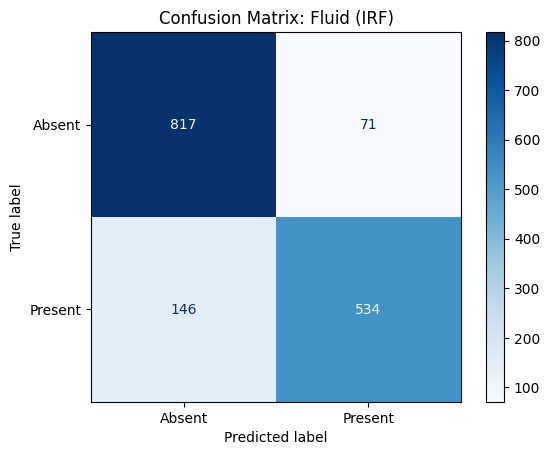

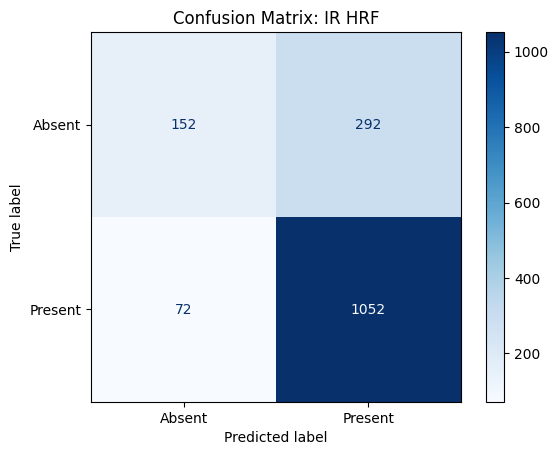

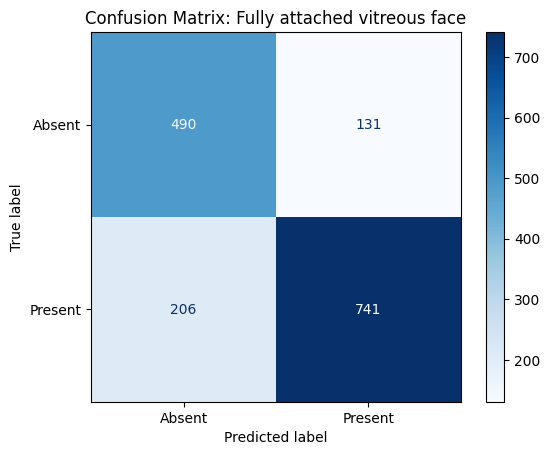

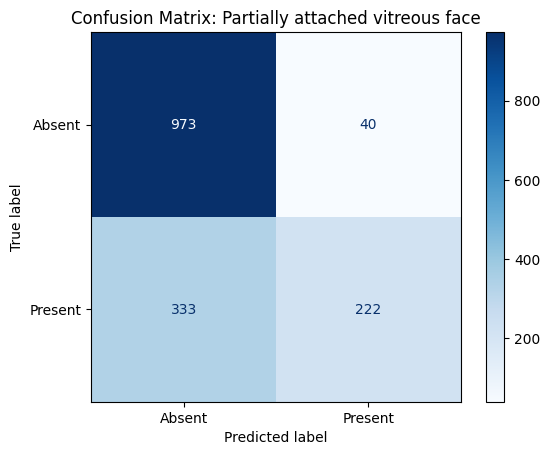

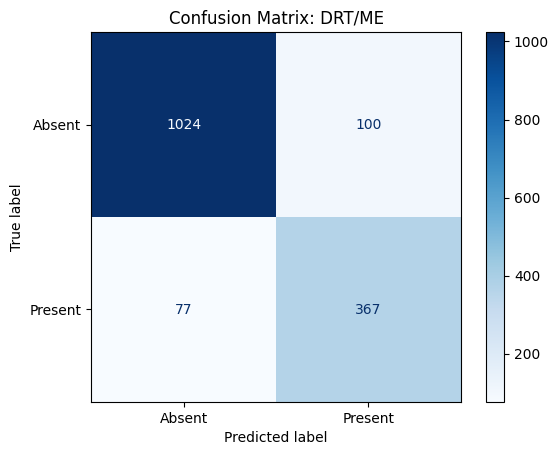

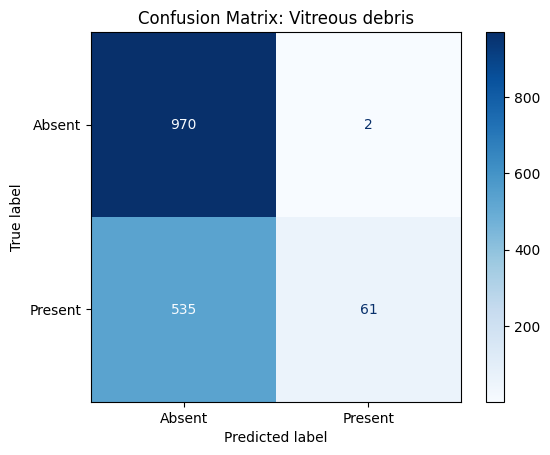

In [ ]:
produce_biomarker_confusion_matrices(biomarker_all_preds, biomarker_all_targets, biomarker_targets)

In [ ]:
produce_classification_report(biomarker_all_preds, biomarker_all_targets, disease_all_preds, disease_all_targets, biomarker_targets)

              precision    recall  f1-score   support

          DR       0.91      0.85      0.88       784
         DME       0.86      0.92      0.89       784

    accuracy                           0.89      1568
   macro avg       0.89      0.89      0.89      1568
weighted avg       0.89      0.89      0.89      1568


Fluid (IRF) - Accuracy: 0.8616, Precision: 0.8826, Recall: 0.7853, F1 Score: 0.8311

IR HRF - Accuracy: 0.7679, Precision: 0.7827, Recall: 0.9359, F1 Score: 0.8525

Fully attached vitreous face - Accuracy: 0.7851, Precision: 0.8498, Recall: 0.7825, F1 Score: 0.8147

Partially attached vitreous face - Accuracy: 0.7621, Precision: 0.8473, Recall: 0.4000, F1 Score: 0.5435

DRT/ME - Accuracy: 0.8871, Precision: 0.7859, Recall: 0.8266, F1 Score: 0.8057

Vitreous debris - Accuracy: 0.6575, Precision: 0.9683, Recall: 0.1023, F1 Score: 0.1851

Macro-average F1-score across all biomarkers: 0.6721
Macro-average accuracy across all biomarkers: 0.7869


In [ ]:
import pandas as pd

biomarker_targets = [
      "Fluid (IRF)",
      "IR HRF",
      "Fully attached vitreous face",
      "Partially attached vitreous face",
      "DRT/ME",
      "Vitreous debris"
  ]

summary = []

for biomarker_name in biomarker_targets:
    y_true = np.array(biomarker_all_targets[biomarker_name])
    unique, counts = np.unique(y_true, return_counts=True)
    count_dict = dict(zip(unique, counts))
    summary.append({
        "Biomarker": biomarker_name,
        "Negative": count_dict.get(0, 0),
        "Positive": count_dict.get(1, 0),
    })

summary_df = pd.DataFrame(summary)
print(summary_df)



                          Biomarker  Negative  Positive
0                       Fluid (IRF)      3176       695
1                            IR HRF      2667      1204
2      Fully attached vitreous face      1861      2010
3  Partially attached vitreous face      2652      1219
4                            DRT/ME      3728       143
5                   Vitreous debris      3445       426


# Get Summary of Data

In [ ]:
import pandas as pd

summary = []
for biomarker_name in biomarker_targets:
    y_true = np.array(all_targets[biomarker_name])
    unique, counts = np.unique(y_true, return_counts=True)
    count_dict = dict(zip(unique, counts))
    summary.append({
        "Biomarker": biomarker_name,
        "Negative": count_dict.get(0, 0),
        "Positive": count_dict.get(1, 0),
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

# Create T-SNE Plots

In [ ]:
from tqdm import tqdm

# Define lists to save to FAISS later
all_features = []
all_labels = []

all_splits_features = []
all_splits_labels = []

# Here, we want to run inference and extract the learned features/embeddings.
with torch.no_grad():
  # Extract features from our test_dataloader dataset
    for batch in tqdm(train_dataloader, desc="Extracting training features"):
        images = batch['image pixel values'].to(device)
        labels = batch['label'].long().to(device)
        biomarkers = batch['biomarkers'].float().to(device)

        images = images.to(device)

        # Extract features just before disease head
        _, _, features = model(images, return_features=True)  # shape: [B, 256]
        features = features.cpu().numpy().astype("float32")   # FAISS expects float32

        all_features.append(features) # Features per sample
        all_labels.extend(labels.cpu().numpy()) # Labels per sample
        all_splits_features.append(features)
        all_splits_labels.extend(labels.cpu().numpy())

with torch.no_grad():
    # Extract features from our test_dataloader dataset
    for batch in tqdm(test_dataloader, desc="Extracting testing features"):
        images = batch['image pixel values'].to(device)
        labels = batch['label'].long().to(device)
        biomarkers = batch['biomarkers'].float().to(device)

        images = images.to(device)

        # Extract features just before disease head
        _, _, features = model(images, return_features=True)  # shape: [B, 256]
        features = features.cpu().numpy().astype("float32")   # FAISS expects float32

        all_features.append(features) # Features per sample
        all_labels.extend(labels.cpu().numpy()) # Labels per sample
        all_splits_features.append(features)

        test_labels_with_offset = labels.cpu().numpy() + 2  # DR test=2, DME test=3
        all_splits_labels.extend(test_labels_with_offset)


features_matrix = np.vstack(all_features)
labels_array = np.array(all_labels)

combined_features_matrix = np.vstack(all_splits_features)
combined_labels_array = np.array(all_splits_labels)

Extracting testing features: 100%|██████████| 1568/1568 [00:20<00:00, 78.07it/s]


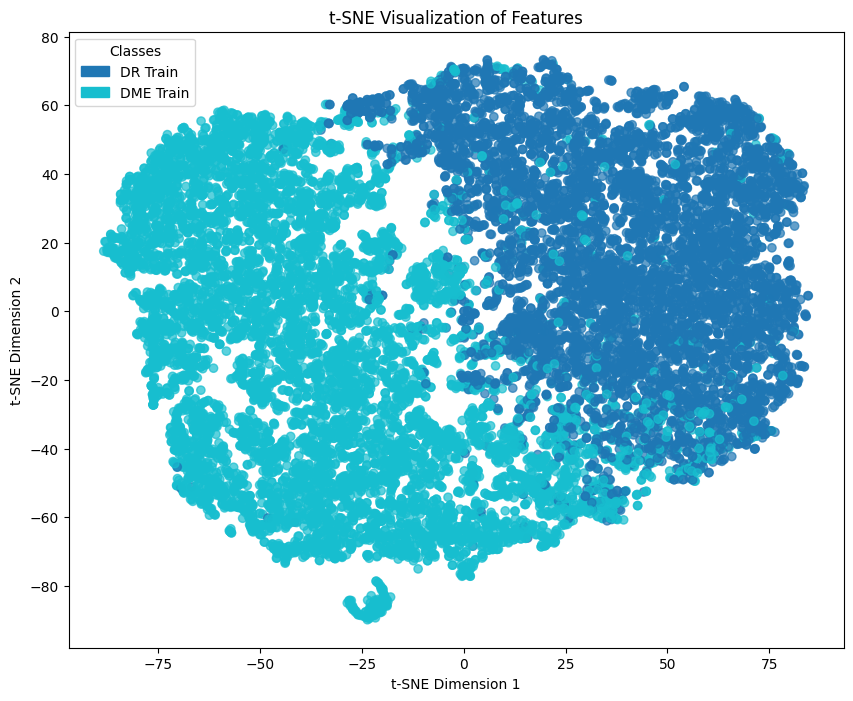

<Figure size 640x480 with 0 Axes>

In [ ]:
# class mapping
class_mapping = {0: "DR Train", 1: "DME Train"}
class_names = [class_mapping[i] for i in range(len(class_mapping))]

# Run t-SNE (assuming features_matrix is your feature array)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
features_2d_training = tsne.fit_transform(features_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d_training[:, 0], features_2d_training[:, 1], c=labels_array, cmap='tab10', alpha=0.7)

# Create legend handles matching colors
handles = []
colors = [scatter.cmap(scatter.norm(i)) for i in range(len(class_names))]

for color, label in zip(colors, class_names):
    patch = mpatches.Patch(color=color, label=label)
    handles.append(patch)

plt.legend(handles=handles, title='Classes')
plt.title("t-SNE Visualization of Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

plt.savefig('Final T-SNE Plot.png', dpi=300, bbox_inches='tight')


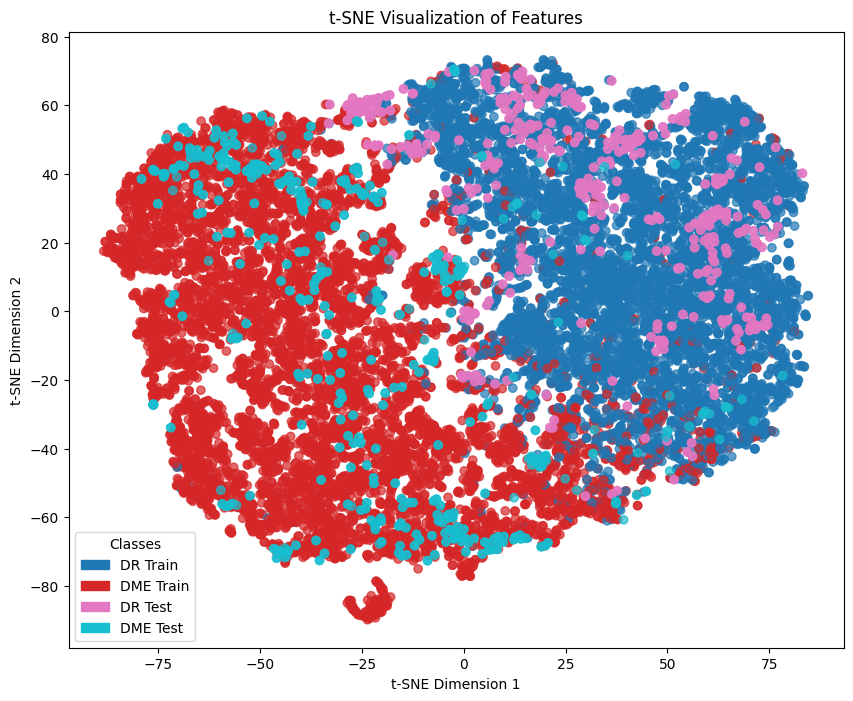

<Figure size 640x480 with 0 Axes>

In [ ]:
class_mapping = {0: "DR Train", 1: "DME Train", 2: "DR Test", 3: "DME Test"}
class_names = [class_mapping[i] for i in range(len(class_mapping))]


# Run t-SNE (assuming features_matrix is your feature array)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
features_2d_combined = tsne.fit_transform(combined_features_matrix)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d_combined[:, 0], features_2d_combined[:, 1], c=combined_labels_array, cmap='tab10', alpha=0.7)

# Create legend handles matching colors
handles = []
colors = [scatter.cmap(scatter.norm(i)) for i in range(len(class_names))]

for color, label in zip(colors, class_names):
    patch = mpatches.Patch(color=color, label=label)
    handles.append(patch)

plt.legend(handles=handles, title='Classes')
plt.title("t-SNE Visualization of Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

plt.savefig('Final T-SNE Plot.png', dpi=300, bbox_inches='tight')


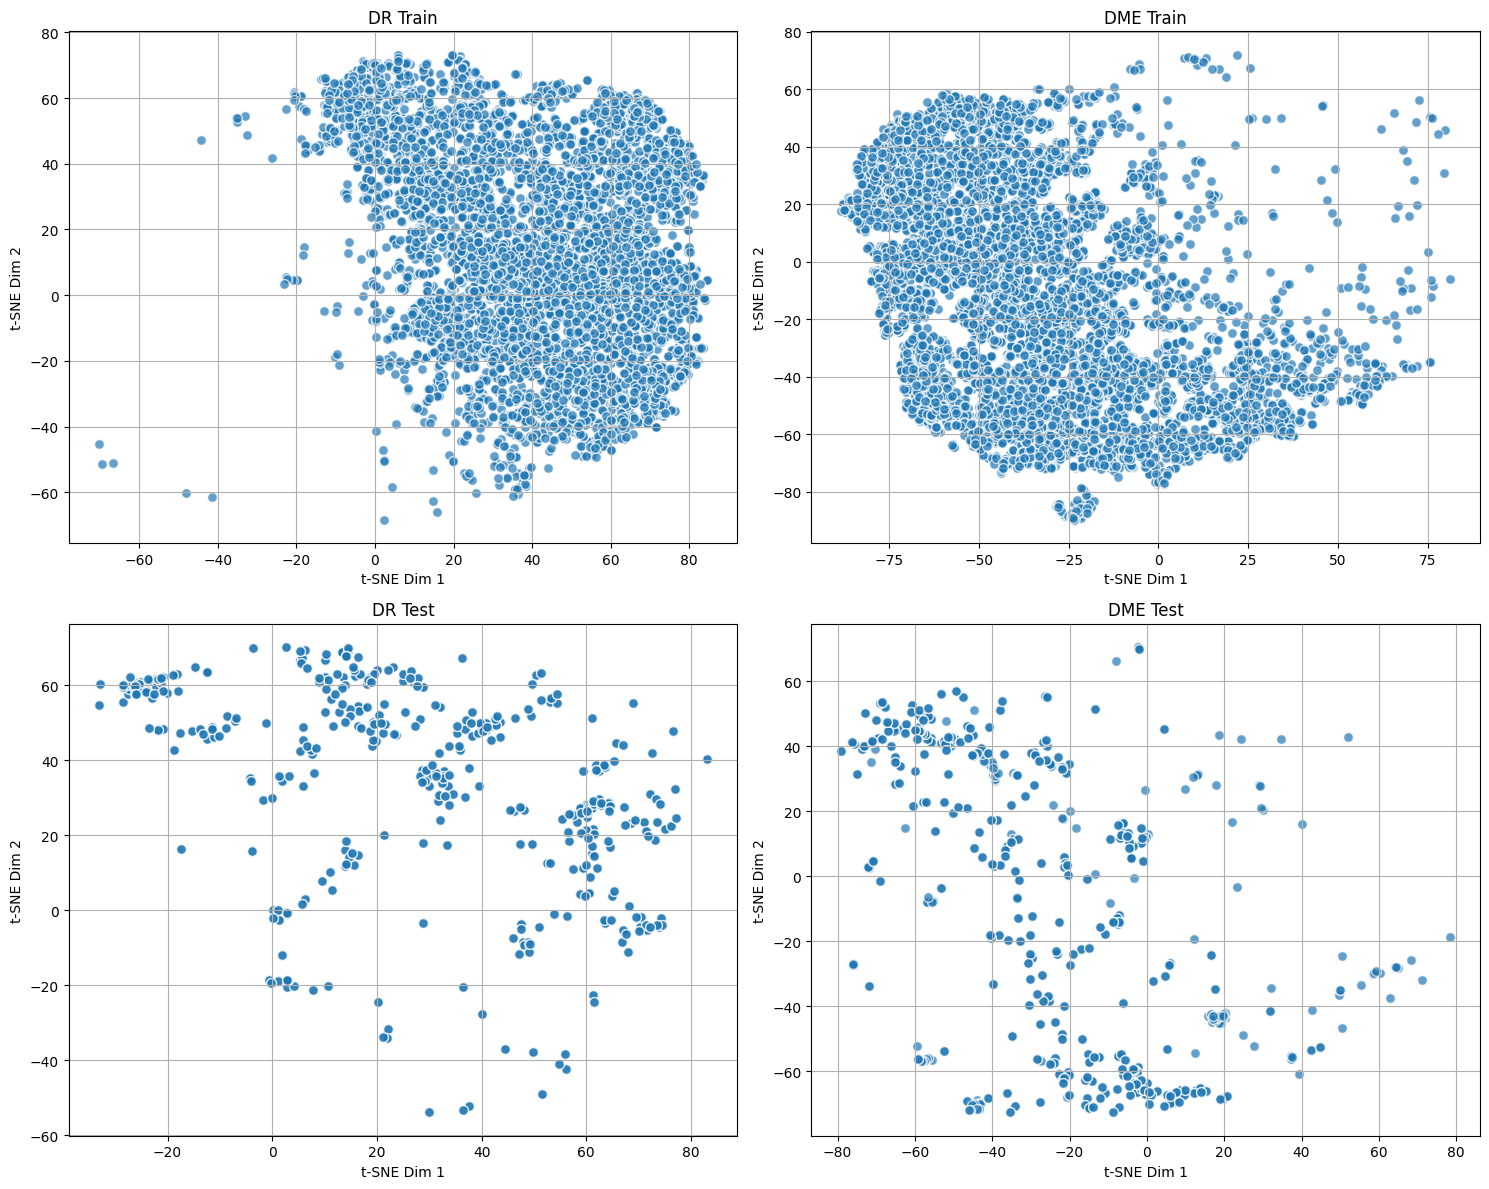

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

for label_id, ax in enumerate(axs):
    idxs = combined_labels_array == label_id
    ax.scatter(features_2d_combined[idxs, 0], features_2d_combined[idxs, 1],
               c='tab:blue', alpha=0.7, edgecolors='w', s=50)
    ax.set_title(class_mapping[label_id])
    ax.set_xlabel("t-SNE Dim 1")
    ax.set_ylabel("t-SNE Dim 2")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Scratch

In [ ]:
from tqdm import tqdm

# Define lists to save to FAISS later
all_features = []
all_labels = []
all_biomarkers = []

# Here, we want to run inference and extract the learned features/embeddings.
with torch.no_grad():
  # Extract features from our test_dataloader dataset
    for batch in tqdm(train_dataloader, desc="Extracting features @ training"):
        images = batch['image pixel values'].to(device)
        labels = batch['label'].long().to(device)
        biomarkers = batch['biomarkers'].float().to(device)

        images = images.to(device)

        # Extract features just before disease head
        _, _, features = model(images, return_features=True)  # shape: [B, 256]
        features = features.cpu().numpy().astype("float32")   # FAISS expects float32

        all_features.append(features) # Features per sample
        all_labels.extend(labels.cpu().numpy()) # Labels per sample
        all_biomarkers.extend(biomarkers.cpu().numpy())  # Biomarkers per sample


Extracting features @ training: 100%|██████████| 446/446 [00:51<00:00,  8.74it/s]


In [ ]:
features_matrix = np.vstack(all_features)
labels_array = np.array(all_labels)
biomarkers_array = np.array(all_biomarkers)

print(features_matrix.shape)


(14247, 256)


In [ ]:
import faiss
import numpy as np
import os

def normalize_vectors(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / norms

# Normalize your feature matrix
features_matrix = normalize_vectors(features_matrix)

d = features_matrix.shape[1]  # Feature size (2048)

# Build FAISS index with L2 distance
index = faiss.IndexFlatL2(d)
index.add(features_matrix)

save_date = "Jun_21"
save_dir = f"/content/drive/MyDrive/Indicium/FAISS_indexes/{save_date}_Jun21-epoch18-finetuned"
os.makedirs(save_dir, exist_ok=True)

# Save index
faiss.write_index(index, f"{save_dir}/oct_features.index")

# Save labels (for ID mapping)
np.save(f"{save_dir}/oct_labels.npy", labels_array)
np.save(f"{save_dir}/oct_biomarkers.npy", biomarkers_array)
